#**Actividad 13: Implementación de un Autoencoder en una Red Denoising usando el dataset MNIST en Google Colab**

En esta actividad se utiliza el dataset fashion-MNIST que tiene dentro de su colección imágenes de zapatos, bolsos camisetas etc.

Lo que se busca con este modelo es la demostración de:


*   encoder
*   decoder
*   compresión
*   reconstrucción
*   eliminación de ruido
*   aprendizaje no supervisado

#**Conceptos Importantes**

#*   Autoencoder
Red Neuronal que comprime información, aprende representación interna y reconstruye los datos originales.

#*   Denoising Autoencoder

Es un modelo entrenado para eliminar ruidos de las imágenes



#**Importar Librerías**

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt


factor=0.3
epocas=50

#**Cargar Dataset**

In [46]:
(X_train, _), (X_test, _)=keras.datasets.fashion_mnist.load_data()

#**Normalización**

In [47]:
X_train=X_train.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0

#**Aplanar imágenes**

In [48]:
X_train=X_train.reshape(-1, 784)
X_test=X_test.reshape(-1, 784)

#**Adición de Ruido Artificial**

In [49]:
X_train_noisy=X_train+factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_test_noisy=X_test+factor*np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape


)
#Limitar Valores

X_train_noisy=np.clip(X_train_noisy, 0., 1.)
X_test_noisy=np.clip(X_test_noisy, 0., 1.)

#**Autodecoder**

In [50]:
#Encoder
#Comprime la información

input_img=keras.Input(shape=(784,))

encoded=layers.Dense(128, activation='relu')(input_img)
encoded=layers.Dense(64, activation='relu')(encoded)
encoded=layers.Dense(32, activation='relu')(encoded)

#Decoder
#Reconstruye la imagen

decoded=layers.Dense(64, activation='relu')(encoded)
decoded=layers.Dense(128, activation='relu')(decoded)
decoded=layers.Dense(784, activation='sigmoid')(decoded)

#Modelo Completo

autoencoder=keras.Model(input_img, decoded)

#**Compilación**

In [51]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
#Adam optimiza los pesos
#Binary crossentropy mide la diferencia reconstrucción

#**Entrenamiento**

En este paso el modelo aprende a:


*   Identifica patrones reales
*   ignora ruido
*   Reconstruye objetos



In [52]:
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=epocas,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.3857 - val_loss: 0.3265
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3172 - val_loss: 0.3155
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3104 - val_loss: 0.3105
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3058 - val_loss: 0.3060
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.3027 - val_loss: 0.3042
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.3006 - val_loss: 0.3021
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.2991 - val_loss: 0.3006
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.2977 - val_loss: 0.2998
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2963 - val_loss: 0.2982
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.2952 - val_loss: 0.2973
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.2943 - val_loss: 0.2965
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

#**Reconstrucción**

In [53]:
decoded_imgs=autoencoder.predict(X_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


#**Visualización Comparativa**

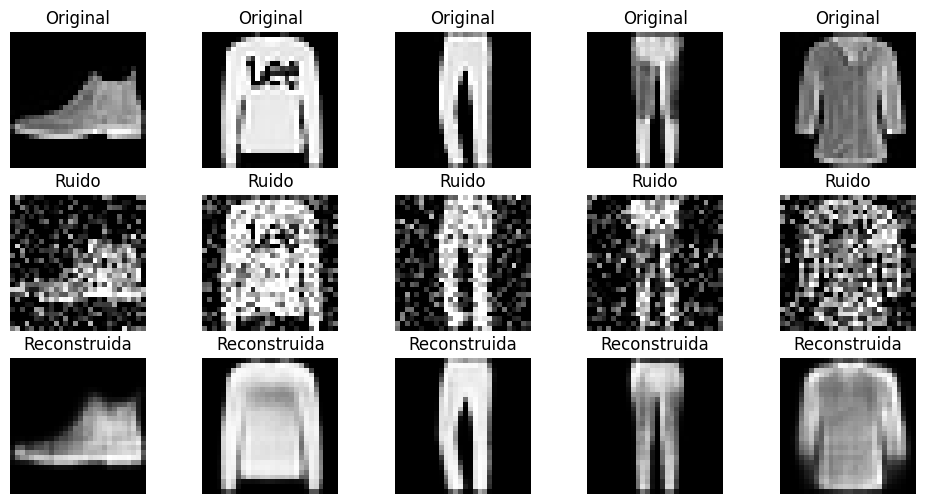

In [54]:
n=5

plt.figure(figsize=(12,6))

for i in range(n):
    #Original
    ax=plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    #Ruido
    ax=plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Ruido")
    plt.axis("off")

    #Reconstruida

    ax=plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Reconstruida")
    plt.axis("off")

plt.show()

#**Gráfica de Loss**

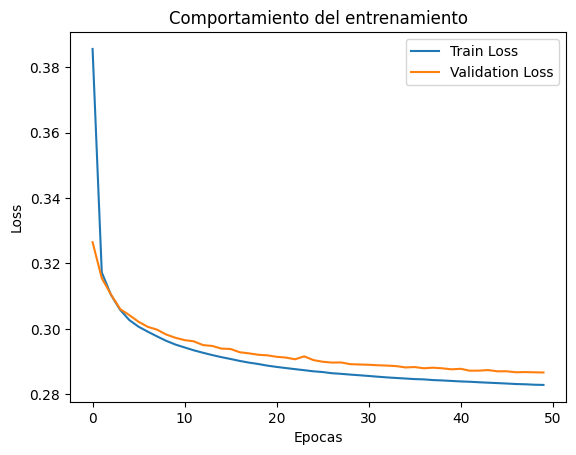

In [55]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epocas")
plt.ylabel("Loss")
plt.legend()
plt.title("Comportamiento del entrenamiento")

plt.show()